# XLSTM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/xlstm_checkpoints', exist_ok=True)
CSV = '/content/drive/MyDrive/xlstm_checkpoints/xlstm_results.csv'

print("exists:", os.path.exists(CSV))
if os.path.exists(CSV):
    import pandas as pd
    print(len(pd.read_csv(CSV)), "rows already saved")

Mounted at /content/drive
exists: True
26696 rows already saved


In [2]:
import os
import sys
import time
import gc
import subprocess
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
import gdown

SHARED_DIR = "shared"
gdown.download_folder(id="1ivElb2AifDNvIg47Ii6dV_XP9aO14WSE", output=SHARED_DIR, quiet=True)
sys.path.append(SHARED_DIR)
import bih_shared as bs

CLEAN_CSV = "bih_hourly_clean.csv"
if not os.path.exists(CLEAN_CSV):
    gdown.download(id="1QyfzghimgyRhQ735k42JetDEoK5kfGZJ", output=CLEAN_CSV, quiet=False)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    print(f"using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("no GPU detected — go to Runtime > Change runtime type > GPU (T4 is fine) "
          "and rerun this cell for the biggest speedup available. Everything below "
          "still runs on CPU, just without that boost.")



def build_train_origins(panel, split, station, pollutant, horizon):
    s = panel[(station, pollutant)]
    y = s.y.to_numpy()
    filled = s.filled.to_numpy()
    real = ~np.isnan(y) & ~filled

    hour_of_day = split["origin_hour_of_day"]
    min_real_target = split["masking"]["min_real_target_hours"]

    train_start = pd.Timestamp(split["train"]["start"])
    train_end = pd.Timestamp(split["train"]["end"])
    candidates = s.index[(s.index >= train_start) & (s.index <= train_end)
                          & (s.index.hour == hour_of_day)]

    origins = []
    for ts in candidates:
        o = s.index.get_loc(ts)
        if o + horizon > len(y):
            continue
        if real[o:o + horizon].sum() < min_real_target:
            continue
        if not np.isfinite(y[max(0, o - 168):o]).any():
            continue
        origins.append(ts)
    return origins


def build_tensor_windows(panel, station, pollutant, origins, lookback, horizon, mu, sigma):

    sigma = sigma if sigma > 1e-6 else 1.0
    n = len(origins)
    X = np.zeros((n, lookback, 2), dtype=np.float32)
    Y = np.zeros((n, horizon), dtype=np.float32)
    M = np.zeros((n, horizon), dtype=np.float32)

    for i, origin in enumerate(origins):
        ctx = bs.context(panel, station, pollutant, origin, lookback)
        if len(ctx) < lookback:
            pad = np.full(lookback - len(ctx), np.nan, dtype=ctx.dtype)
            ctx = np.concatenate([pad, ctx])
        observed = np.isfinite(ctx).astype(np.float32)
        ctx_norm = np.nan_to_num((ctx - mu) / sigma, nan=0.0).astype(np.float32)

        y, mask = bs.target(panel, station, pollutant, origin, horizon)
        y_norm = np.nan_to_num((y - mu) / sigma, nan=0.0).astype(np.float32)

        X[i, :, 0] = ctx_norm
        X[i, :, 1] = observed
        Y[i] = y_norm
        M[i] = mask.astype(np.float32)

    return torch.from_numpy(X), torch.from_numpy(Y), torch.from_numpy(M)


class TensorWindows:


    def __init__(self, X, Y, M, origins, horizon, device):
        self.X = X.to(device)
        self.Y = Y.to(device)
        self.M = M.to(device)
        self.origins = origins
        self.horizon = horizon

    def __len__(self):
        return self.X.shape[0]



class sLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W = nn.Linear(input_size, 4 * hidden_size)
        self.R = nn.Linear(hidden_size, 4 * hidden_size, bias=False)

    def forward(self, x_t, state):
        h, c, n, m = state
        gates = self.W(x_t) + self.R(h)
        z, i_tilde, f_tilde, o_tilde = gates.chunk(4, dim=-1)

        z = torch.tanh(z)
        o = torch.sigmoid(o_tilde)

        m_new = torch.maximum(f_tilde + m, i_tilde)
        i = torch.exp(i_tilde - m_new)
        f = torch.exp(f_tilde + m - m_new)

        c_new = f * c + i * z
        n_new = f * n + i
        h_new = o * (c_new / n_new.clamp_min(1e-6))

        return h_new, (h_new, c_new, n_new, m_new)

    def init_state(self, batch_size, device):
        z = torch.zeros(batch_size, self.hidden_size, device=device)
        return (z, z, z, z)


class mLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.Wq = nn.Linear(input_size, hidden_size)
        self.Wk = nn.Linear(input_size, hidden_size)
        self.Wv = nn.Linear(input_size, hidden_size)
        self.Wi = nn.Linear(input_size, 1)
        self.Wf = nn.Linear(input_size, 1)
        self.Wo = nn.Linear(input_size, hidden_size)

    def forward(self, x_t, state):
        C, n, m = state

        q = self.Wq(x_t)
        k = self.Wk(x_t) / math.sqrt(self.hidden_size)
        v = self.Wv(x_t)
        i_tilde = self.Wi(x_t)
        f_tilde = self.Wf(x_t)
        o = torch.sigmoid(self.Wo(x_t))

        m_new = torch.maximum(f_tilde + m, i_tilde)
        i = torch.exp(i_tilde - m_new)
        f = torch.exp(f_tilde + m - m_new)

        C_new = f.unsqueeze(-1) * C + i.unsqueeze(-1) * torch.einsum("bh,bk->bhk", v, k)
        n_new = f * n + i * k

        h = o * torch.einsum("bhk,bk->bh", C_new, q) / \
            torch.einsum("bh,bh->b", n_new, q).clamp_min(1e-6).unsqueeze(-1)

        return h, (C_new, n_new, m_new)

    def init_state(self, batch_size, device):
        C = torch.zeros(batch_size, self.hidden_size, self.hidden_size, device=device)
        n = torch.zeros(batch_size, self.hidden_size, device=device)
        m = torch.zeros(batch_size, 1, device=device)
        return (C, n, m)


class xLSTMBlock(nn.Module):
    def __init__(self, input_size, hidden_size, kind="m"):
        super().__init__()
        self.kind = kind
        self.cell = mLSTMCell(input_size, hidden_size) if kind == "m" else sLSTMCell(input_size, hidden_size)
        self.norm = nn.LayerNorm(input_size)
        self.proj = nn.Linear(hidden_size, input_size) if hidden_size != input_size else nn.Identity()

    def forward(self, x):
        B, T, D = x.shape
        state = self.cell.init_state(B, x.device)
        x_norm = self.norm(x)
        outs = []
        for t in range(T):
            h, state = self.cell(x_norm[:, t], state)
            outs.append(h)
        h_seq = torch.stack(outs, dim=1)
        return x + self.proj(h_seq)


class xLSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=64, horizon=24, block_types=("m", "s", "m", "s")):
        super().__init__()
        self.in_proj = nn.Linear(n_features, hidden_size)
        self.blocks = nn.ModuleList([
            xLSTMBlock(hidden_size, hidden_size, kind=k) for k in block_types
        ])
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        h = self.in_proj(x)
        for block in self.blocks:
            h = block(h)
        return self.head(h[:, -1])



def masked_l1_loss(pred, y, mask):
    err = torch.abs(pred - y) * mask
    return err.sum() / mask.sum().clamp_min(1)


def train_one_station(station, pollutant, lookback=168, horizon=24,
                       hidden_size=64, epochs=20, batch_size=256, lr=1e-3,
                       device=None, patience=3, min_delta=1e-4, verbose=True,
                       panel=None):

    device = device or DEVICE
    use_amp = False  # xLSTM's exp(i_tilde - m_new) gating overflows in fp16 -> NaN loss

    split = bs.load_split(SHARED_DIR)
    groups = bs.load_groups(SHARED_DIR)
    status = groups["by_station"].get(station, {}).get(pollutant)
    if status != "ok":
        raise ValueError(f"{station}-{pollutant} is '{status}', not eligible for training")

    panel = panel if panel is not None else bs.load_panel(CLEAN_CSV, SHARED_DIR)
    windows = bs.load_windows(SHARED_DIR)

    s = panel[(station, pollutant)]
    train_start, train_end = pd.Timestamp(split["train"]["start"]), pd.Timestamp(split["train"]["end"])
    train_vals = s.y.to_numpy()[(s.index >= train_start) & (s.index <= train_end)]
    mu, sigma = float(np.nanmean(train_vals)), float(np.nanstd(train_vals))

    train_origins = build_train_origins(panel, split, station, pollutant, horizon)
    val_origins = windows[(windows.station == station) & (windows.pollutant == pollutant)] \
        .origin.tolist()

    Xtr, Ytr, Mtr = build_tensor_windows(panel, station, pollutant, train_origins, lookback, horizon, mu, sigma)
    if val_origins:
        Xval, Yval, Mval = build_tensor_windows(panel, station, pollutant, val_origins, lookback, horizon, mu, sigma)
    else:
        Xval, Yval, Mval = (torch.empty(0, lookback, 2), torch.empty(0, horizon), torch.empty(0, horizon))

    train_ds = TensorWindows(Xtr, Ytr, Mtr, train_origins, horizon, device)
    val_ds = TensorWindows(Xval, Yval, Mval, val_origins, horizon, device)

    model = xLSTMForecaster(n_features=2, hidden_size=hidden_size, horizon=horizon).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if device.type == "cuda" else None

    n = len(train_ds)
    if n == 0:
        raise ValueError(f"{station}-{pollutant}: 0 eligible train origins")

    best_loss, bad_epochs = float("inf"), 0

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        total_loss, total_n = 0.0, 0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            x, y, mask = train_ds.X[idx], train_ds.Y[idx], train_ds.M[idx]

            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=use_amp):
                pred = model(x)
                loss = masked_l1_loss(pred, y, mask)
            if scaler is not None:
                scaler.scale(loss).backward()
                if use_amp:
                    scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(opt)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                opt.step()

            total_loss += loss.item() * x.size(0)
            total_n += x.size(0)

        epoch_loss = total_loss / max(total_n, 1)
        if verbose:
            print(f"[{station}-{pollutant}] epoch {epoch + 1}: train MAE (normalized)={epoch_loss:.4f}")

        if epoch_loss < best_loss - min_delta:
            best_loss, bad_epochs = epoch_loss, 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"[{station}-{pollutant}] early stop at epoch {epoch + 1} "
                          f"(no improvement for {patience} epochs)")
                break

    return model, val_ds, panel, mu, sigma


def evaluate(model, val_ds, panel, station, pollutant, mu, sigma, device=None):

    device = device or DEVICE
    model.eval()
    rows = []

    if len(val_ds) == 0:
        print(f"no eval windows for {station}-{pollutant} in eval_windows.csv — skipping scoring")
        return pd.DataFrame(), None

    with torch.no_grad():
        pred_norm = model(val_ds.X).cpu().numpy()
    all_preds = pred_norm * sigma + mu

    for i, origin in enumerate(val_ds.origins):
        y, mask = bs.target(panel, station, pollutant, origin, val_ds.horizon)
        ctx = bs.context(panel, station, pollutant, origin, 512)
        scale = bs.mase_scale(ctx)
        rows.append({"model": "xlstm", "station": station, "pollutant": pollutant,
                     "origin": origin, **bs.score(all_preds[i], y, mask, scale)})

    result = pd.DataFrame(rows)
    per_pol = bs.aggregate(result.to_dict("records"))

    baseline_row = "persistence_last" if pollutant == "so2" else "persistence_t24"
    print(f"xLSTM vs the bar it needs to clear ({baseline_row}):")
    print(per_pol)
    print(f"(compare against baseline_metrics.csv, pollutant={pollutant}, "
          f"model={baseline_row})")
    return result, per_pol


def run_all(lookback=168, horizon=24, epochs=20, device=None, out_csv="xlstm_results.csv",
            limit=None, batch_size=256, patience=3):

    device = device or DEVICE
    groups = bs.load_groups(SHARED_DIR)
    panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)

    pairs = [(st, p) for p in bs.POLLUTANTS
             for st in groups["by_pollutant"][p]["ok"]]

    done = set()
    if os.path.exists(out_csv):
        prev = pd.read_csv(out_csv)
        done = set(zip(prev.station, prev.pollutant))
        print(f"{len(done)} station-pollutant pairs already in {out_csv}, skipping those")

    remaining = [pair for pair in pairs if pair not in done]
    print(f"{len(pairs)} total pairs, {len(remaining)} remaining")

    batch = remaining[:limit] if limit else remaining
    if limit:
        print(f"running this batch: {batch}")

    for station, pollutant in batch:
        t0 = time.time()
        try:
            model, val_ds, _, mu, sigma = train_one_station(
                station, pollutant, lookback=lookback, horizon=horizon,
                epochs=epochs, device=device, batch_size=batch_size, patience=patience,
                panel=panel)
            result, _ = evaluate(model, val_ds, panel, station, pollutant, mu, sigma, device=device)
            if len(result) == 0:
                continue
            header = not os.path.exists(out_csv)
            result.to_csv(out_csv, mode="a", header=header, index=False)
            del model, val_ds, result
            gc.collect()
        except Exception as e:
            print(f"SKIPPED {station}-{pollutant}: {e}")
        print(f"[{station}-{pollutant}] wall time: {time.time() - t0:.1f}s\n")

    full = pd.read_csv(out_csv)
    per_pol = bs.aggregate(full.to_dict("records"))
    print("\nFULL SUMMARY SO FAR — xLSTM, per pollutant, native units:\n")
    print(per_pol)
    still_left = len(remaining) - len(batch)
    print(f"\n{out_csv} has {len(full)} rows total. {still_left} pairs still not run"
          f"{' — call run_all(limit=5) again for the next batch.' if still_left else '.'}")
    return full, per_pol


def plot_results(out_csv="xlstm_results.csv"):

    import matplotlib.pyplot as plt

    full = pd.read_csv(out_csv)
    pollutants = sorted(full.pollutant.unique())

    fig, axes = plt.subplots(len(pollutants), 1, figsize=(10, 3.5 * len(pollutants)), squeeze=False)
    axes = axes.ravel()

    for ax, pollutant in zip(axes, pollutants):
        sub = full[full.pollutant == pollutant].groupby("station").mase.median().sort_values()
        colors = ["tab:green" if v < 1.0 else "tab:red" for v in sub.values]
        ax.barh(sub.index, sub.values, color=colors)
        ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{pollutant.upper()} — median MASE by station (below 1.0 beats the baseline)")
        ax.set_xlabel("median MASE")

    plt.tight_layout()
    plt.savefig("xlstm_mase_by_station.png", dpi=150)
    plt.show()
    print("saved xlstm_mase_by_station.png")


def inspect_outliers(station, pollutant, out_csv="xlstm_results.csv", top_n=10):

    full = pd.read_csv(out_csv)
    sub = full[(full.station == station) & (full.pollutant == pollutant)]
    sub = sub.sort_values("mase", ascending=False)
    print(f"{len(sub)} windows for {station}-{pollutant}")
    print(f"mean MASE: {sub.mase.mean():.3f}   median MASE: {sub.mase.median():.3f}")
    print(f"\ntop {top_n} worst windows:")
    print(sub[["origin", "mae", "rmse", "mase"]].head(top_n).to_string(index=False))
    return sub


def progress(out_csv="xlstm_results.csv"):

    groups = bs.load_groups(SHARED_DIR)
    pairs = [(st, p) for p in bs.POLLUTANTS for st in groups["by_pollutant"][p]["ok"]]

    done = set()
    if os.path.exists(out_csv):
        prev = pd.read_csv(out_csv)
        done = set(zip(prev.station, prev.pollutant))

    remaining = [pair for pair in pairs if pair not in done]
    print(f"{len(pairs)} total pairs")
    print(f"{len(done)} done")
    print(f"{len(remaining)} remaining ({len(remaining) // 5 + (1 if len(remaining) % 5 else 0)} more batches of 5)")
    if remaining:
        print("\nnext up:", remaining[:5])
    return pairs, done, remaining

Downloading...
From (original): https://drive.google.com/uc?id=1QyfzghimgyRhQ735k42JetDEoK5kfGZJ
From (redirected): https://drive.google.com/uc?id=1QyfzghimgyRhQ735k42JetDEoK5kfGZJ&confirm=t&uuid=70e2411a-5274-460a-bed2-2ff30ac90b11
To: /content/bih_hourly_clean.csv
100%|██████████| 167M/167M [00:02<00:00, 59.1MB/s]


using GPU: Tesla T4


In [ ]:
run_all(out_csv=CSV)

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

16 station-pollutant pairs already in /content/drive/MyDrive/xlstm_checkpoints/xlstm_results.csv, skipping those
95 total pairs, 79 remaining


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Ambasada-pm25] epoch 1: train MAE (normalized)=60679.9313
[Ambasada-pm25] epoch 2: train MAE (normalized)=21864.7134
[Ambasada-pm25] epoch 3: train MAE (normalized)=4872.0798
[Ambasada-pm25] epoch 4: train MAE (normalized)=694.4015
[Ambasada-pm25] epoch 5: train MAE (normalized)=1.0188
[Ambasada-pm25] epoch 6: train MAE (normalized)=0.6172
[Ambasada-pm25] epoch 7: train MAE (normalized)=0.5373
[Ambasada-pm25] epoch 8: train MAE (normalized)=0.4972
[Ambasada-pm25] epoch 9: train MAE (normalized)=0.4614
[Ambasada-pm25] epoch 10: train MAE (normalized)=0.4327
[Ambasada-pm25] epoch 11: train MAE (normalized)=0.4126
[Ambasada-pm25] epoch 12: train MAE (normalized)=0.3951
[Ambasada-pm25] epoch 13: train MAE (normalized)=0.3873
[Ambasada-pm25] epoch 14: train MAE (normalized)=8.3257
[Ambasada-pm25] epoch 15: train MAE (normalized)=0.3780
[Ambasada-pm25] epoch 16: train MAE (normalized)=0.3748
[Ambasada-pm25] epoch 17: train MAE (normalized)=0.3725
[Ambasada-pm25] epoch 18: train MAE (normali

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

...

[Vijecnica-no2] epoch 1: train MAE (normalized)=156940.2980
[Vijecnica-no2] epoch 2: train MAE (normalized)=0.7378
[Vijecnica-no2] epoch 3: train MAE (normalized)=0.6042
[Vijecnica-no2] epoch 4: train MAE (normalized)=0.5578
[Vijecnica-no2] epoch 5: train MAE (normalized)=0.5369
[Vijecnica-no2] epoch 6: train MAE (normalized)=0.5187
[Vijecnica-no2] epoch 7: train MAE (normalized)=0.5093
[Vijecnica-no2] epoch 8: train MAE (normalized)=0.5034
[Vijecnica-no2] epoch 9: train MAE (normalized)=0.5005
[Vijecnica-no2] epoch 10: train MAE (normalized)=0.4979
[Vijecnica-no2] epoch 11: train MAE (normalized)=0.4954
[Vijecnica-no2] epoch 12: train MAE (normalized)=0.4939
[Vijecnica-no2] epoch 13: train MAE (normalized)=0.4908
[Vijecnica-no2] epoch 14: train MAE (normalized)=0.4886
[Vijecnica-no2] epoch 15: train MAE (normalized)=0.4880
[Vijecnica-no2] epoch 16: train MAE (normalized)=0.4857
[Vijecnica-no2] epoch 17: train MAE (normalized)=0.4836
[Vijecnica-no2] epoch 18: train MAE (normalized)=0.4

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Vogosca-no2] epoch 1: train MAE (normalized)=342004.8964
[Vogosca-no2] epoch 2: train MAE (normalized)=122238.2964
[Vogosca-no2] epoch 3: train MAE (normalized)=7875.6789
[Vogosca-no2] epoch 4: train MAE (normalized)=1088.3191
[Vogosca-no2] epoch 5: train MAE (normalized)=0.7895
[Vogosca-no2] epoch 6: train MAE (normalized)=256.5597
[Vogosca-no2] epoch 7: train MAE (normalized)=0.6905
[Vogosca-no2] epoch 8: train MAE (normalized)=0.6460
[Vogosca-no2] epoch 9: train MAE (normalized)=0.6062
[Vogosca-no2] epoch 10: train MAE (normalized)=0.5729
[Vogosca-no2] epoch 11: train MAE (normalized)=0.5484
[Vogosca-no2] epoch 12: train MAE (normalized)=0.5321
[Vogosca-no2] epoch 13: train MAE (normalized)=0.5220
[Vogosca-no2] epoch 14: train MAE (normalized)=0.5169
[Vogosca-no2] epoch 15: train MAE (normalized)=0.5106
[Vogosca-no2] epoch 16: train MAE (normalized)=0.5029
[Vogosca-no2] epoch 17: train MAE (normalized)=0.4955
[Vogosca-no2] epoch 18: train MAE (normalized)=162.5272
[Vogosca-no2] epo

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Banja Luka-o3] epoch 1: train MAE (normalized)=10616.3520
[Banja Luka-o3] epoch 2: train MAE (normalized)=0.7739
[Banja Luka-o3] epoch 3: train MAE (normalized)=0.6363
[Banja Luka-o3] epoch 4: train MAE (normalized)=0.5708
[Banja Luka-o3] epoch 5: train MAE (normalized)=0.5213
[Banja Luka-o3] epoch 6: train MAE (normalized)=0.4807
[Banja Luka-o3] epoch 7: train MAE (normalized)=0.4466
[Banja Luka-o3] epoch 8: train MAE (normalized)=0.4208
[Banja Luka-o3] epoch 9: train MAE (normalized)=0.4014
[Banja Luka-o3] epoch 10: train MAE (normalized)=9.1125
[Banja Luka-o3] epoch 11: train MAE (normalized)=0.3791
[Banja Luka-o3] epoch 12: train MAE (normalized)=0.3695
[Banja Luka-o3] epoch 13: train MAE (normalized)=0.3619
[Banja Luka-o3] epoch 14: train MAE (normalized)=0.3564
[Banja Luka-o3] epoch 15: train MAE (normalized)=0.3536
[Banja Luka-o3] epoch 16: train MAE (normalized)=0.3498


In [ ]:
import torch
progress(out_csv=CSV)
run_all(out_csv=CSV, limit=5, device=torch.device("cpu"))

95 total pairs
70 done
25 remaining (5 more batches of 5)

next up: [('Ambasada', 'pm25'), ('Bihac', 'o3'), ('Bjelave', 'o3'), ('Brod', 'o3'), ('Doboj', 'o3')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

70 station-pollutant pairs already in /content/drive/MyDrive/xlstm_checkpoints/xlstm_results.csv, skipping those
95 total pairs, 25 remaining
running this batch: [('Ambasada', 'pm25'), ('Bihac', 'o3'), ('Bjelave', 'o3'), ('Brod', 'o3'), ('Doboj', 'o3')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Ambasada-pm25] epoch 1: train MAE (normalized)=85850.3137
[Ambasada-pm25] epoch 2: train MAE (normalized)=3739.3223
[Ambasada-pm25] epoch 3: train MAE (normalized)=1088.6886
[Ambasada-pm25] epoch 4: train MAE (normalized)=22.9011
[Ambasada-pm25] epoch 5: train MAE (normalized)=0.9206
[Ambasada-pm25] epoch 6: train MAE (normalized)=0.5565
[Ambasada-pm25] epoch 7: train MAE (normalized)=0.4992
[Ambasada-pm25] epoch 8: train MAE (normalized)=0.4586
[Ambasada-pm25] epoch 9: train MAE (normalized)=0.4333
[Ambasada-pm25] epoch 10: train MAE (normalized)=0.4109
[Ambasada-pm25] epoch 11: train MAE (normalized)=0.3958
[Ambasada-pm25] epoch 12: train MAE (normalized)=0.3881
[Ambasada-pm25] epoch 13: train MAE (normalized)=0.3820
[Ambasada-pm25] epoch 14: train MAE (normalized)=0.3776
[Ambasada-pm25] epoch 15: train MAE (normalized)=0.3742
[Ambasada-pm25] epoch 16: train MAE (normalized)=0.3718
[Ambasada-pm25] epoch 17: train MAE (normalized)=0.3692
[Ambasada-pm25] epoch 18: train MAE (normalize

...

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Brod-o3] epoch 1: train MAE (normalized)=149349.5896
[Brod-o3] epoch 2: train MAE (normalized)=1.5568
[Brod-o3] epoch 3: train MAE (normalized)=0.6462
[Brod-o3] epoch 4: train MAE (normalized)=4.0600
[Brod-o3] epoch 5: train MAE (normalized)=1803.1159
[Brod-o3] epoch 6: train MAE (normalized)=24864.7309
[Brod-o3] early stop at epoch 6 (no improvement for 3 epochs)
xLSTM vs the bar it needs to clear (persistence_t24):
                         mae          rmse        mase
model pollutant                                       
xlstm o3         8844.096108  11274.837717  830.152809
(compare against baseline_metrics.csv, pollutant=o3, model=persistence_t24)
[Brod-o3] wall time: 295.2s



/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Doboj-o3] epoch 1: train MAE (normalized)=8218.3972
[Doboj-o3] epoch 2: train MAE (normalized)=210.6338
[Doboj-o3] epoch 3: train MAE (normalized)=0.7664
[Doboj-o3] epoch 4: train MAE (normalized)=0.6831
[Doboj-o3] epoch 5: train MAE (normalized)=25.4584
[Doboj-o3] epoch 6: train MAE (normalized)=0.6079
[Doboj-o3] epoch 7: train MAE (normalized)=0.5660
[Doboj-o3] epoch 8: train MAE (normalized)=0.5350
[Doboj-o3] epoch 9: train MAE (normalized)=0.5139
[Doboj-o3] epoch 10: train MAE (normalized)=0.4913
[Doboj-o3] epoch 11: train MAE (normalized)=0.4710
[Doboj-o3] epoch 12: train MAE (normalized)=0.4572
[Doboj-o3] epoch 13: train MAE (normalized)=0.4411
[Doboj-o3] epoch 14: train MAE (normalized)=0.4258
[Doboj-o3] epoch 15: train MAE (normalized)=0.4104
[Doboj-o3] epoch 16: train MAE (normalized)=0.3998
[Doboj-o3] epoch 17: train MAE (normalized)=0.3899
[Doboj-o3] epoch 18: train MAE (normalized)=0.3825
[Doboj-o3] epoch 19: train MAE (normalized)=0.3768
[Doboj-o3] epoch 20: train MAE (no

(       model     station pollutant      origin           mae          rmse  \
 0      xlstm  Banja Luka      pm10  2024-01-01  3.161297e+06  3.925857e+06   
 1      xlstm  Banja Luka      pm10  2024-01-02  9.094431e+06  1.066262e+07   
 2      xlstm  Banja Luka      pm10  2024-01-03  2.872247e+06  3.336524e+06   
 3      xlstm  Banja Luka      pm10  2024-01-04  9.439875e+06  1.092506e+07   
 4      xlstm  Banja Luka      pm10  2024-01-05  1.963518e+07  2.240197e+07   
 ...      ...         ...       ...         ...           ...           ...   
 24103  xlstm       Doboj        o3  2024-12-27  2.793097e+00  3.079101e+00   
 24104  xlstm       Doboj        o3  2024-12-28  2.828585e+00  3.357265e+00   
 24105  xlstm       Doboj        o3  2024-12-29  4.064352e+00  4.782885e+00   
 24106  xlstm       Doboj        o3  2024-12-30  5.182834e+00  7.639602e+00   
 24107  xlstm       Doboj        o3  2024-12-31  3.931054e+00  5.267066e+00   
 
                 mase   n  
 0       55172.922248 

In [ ]:
import torch
run_all(out_csv=CSV, limit=5, device=torch.device("cpu"))

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

74 station-pollutant pairs already in /content/drive/MyDrive/xlstm_checkpoints/xlstm_results.csv, skipping those
95 total pairs, 21 remaining
running this batch: [('Ambasada', 'pm25'), ('Hadzici', 'o3'), ('Isedlo', 'o3'), ('Livno', 'o3'), ('Otoka', 'o3')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Ambasada-pm25] epoch 1: train MAE (normalized)=140090.6847
[Ambasada-pm25] epoch 2: train MAE (normalized)=26692.6869
[Ambasada-pm25] epoch 3: train MAE (normalized)=513.7127
[Ambasada-pm25] epoch 4: train MAE (normalized)=0.5953
[Ambasada-pm25] epoch 5: train MAE (normalized)=0.5056
[Ambasada-pm25] epoch 6: train MAE (normalized)=0.4543
[Ambasada-pm25] epoch 7: train MAE (normalized)=0.4185
[Ambasada-pm25] epoch 8: train MAE (normalized)=0.4005
[Ambasada-pm25] epoch 9: train MAE (normalized)=23.7844
[Ambasada-pm25] epoch 10: train MAE (normalized)=0.3891
[Ambasada-pm25] epoch 11: train MAE (normalized)=0.3795
[Ambasada-pm25] epoch 12: train MAE (normalized)=0.3732
[Ambasada-pm25] epoch 13: train MAE (normalized)=0.3722
[Ambasada-pm25] epoch 14: train MAE (normalized)=0.3704
[Ambasada-pm25] epoch 15: train MAE (normalized)=0.3683
[Ambasada-pm25] epoch 16: train MAE (normalized)=0.3654
[Ambasada-pm25] epoch 17: train MAE (normalized)=0.3644
[Ambasada-pm25] epoch 18: train MAE (normaliz

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

...

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Livno-o3] epoch 1: train MAE (normalized)=5790.9017
[Livno-o3] epoch 2: train MAE (normalized)=0.7511
[Livno-o3] epoch 3: train MAE (normalized)=0.6444
[Livno-o3] epoch 4: train MAE (normalized)=0.5809
[Livno-o3] epoch 5: train MAE (normalized)=0.5344
[Livno-o3] epoch 6: train MAE (normalized)=0.4984
[Livno-o3] epoch 7: train MAE (normalized)=0.4743
[Livno-o3] epoch 8: train MAE (normalized)=0.4623
[Livno-o3] epoch 9: train MAE (normalized)=0.4512
[Livno-o3] epoch 10: train MAE (normalized)=0.4384
[Livno-o3] epoch 11: train MAE (normalized)=0.4296
[Livno-o3] epoch 12: train MAE (normalized)=0.4207
[Livno-o3] epoch 13: train MAE (normalized)=0.4160
[Livno-o3] epoch 14: train MAE (normalized)=0.4118
[Livno-o3] epoch 15: train MAE (normalized)=0.4080
[Livno-o3] epoch 16: train MAE (normalized)=0.4043
[Livno-o3] epoch 17: train MAE (normalized)=0.4009
[Livno-o3] epoch 18: train MAE (normalized)=0.3980
[Livno-o3] epoch 19: train MAE (normalized)=0.3969
[Livno-o3] epoch 20: train MAE (norma

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Otoka-o3] epoch 1: train MAE (normalized)=23018.2540
[Otoka-o3] epoch 2: train MAE (normalized)=46.6989
[Otoka-o3] epoch 3: train MAE (normalized)=0.6502
[Otoka-o3] epoch 4: train MAE (normalized)=0.6047
[Otoka-o3] epoch 5: train MAE (normalized)=521.6276
[Otoka-o3] epoch 6: train MAE (normalized)=34.6566
[Otoka-o3] epoch 7: train MAE (normalized)=0.5018
[Otoka-o3] epoch 8: train MAE (normalized)=0.4788
[Otoka-o3] epoch 9: train MAE (normalized)=0.4676
[Otoka-o3] epoch 10: train MAE (normalized)=0.4563
[Otoka-o3] epoch 11: train MAE (normalized)=0.4443
[Otoka-o3] epoch 12: train MAE (normalized)=0.4353
[Otoka-o3] epoch 13: train MAE (normalized)=2882.2053
[Otoka-o3] epoch 14: train MAE (normalized)=0.4293
[Otoka-o3] epoch 15: train MAE (normalized)=0.4243
[Otoka-o3] epoch 16: train MAE (normalized)=0.4230
[Otoka-o3] epoch 17: train MAE (normalized)=0.4209
[Otoka-o3] epoch 18: train MAE (normalized)=0.4246
[Otoka-o3] epoch 19: train MAE (normalized)=0.4189
[Otoka-o3] epoch 20: train MA

(       model     station pollutant      origin           mae          rmse  \
 0      xlstm  Banja Luka      pm10  2024-01-01  3.161297e+06  3.925857e+06   
 1      xlstm  Banja Luka      pm10  2024-01-02  9.094431e+06  1.066262e+07   
 2      xlstm  Banja Luka      pm10  2024-01-03  2.872247e+06  3.336524e+06   
 3      xlstm  Banja Luka      pm10  2024-01-04  9.439875e+06  1.092506e+07   
 4      xlstm  Banja Luka      pm10  2024-01-05  1.963518e+07  2.240197e+07   
 ...      ...         ...       ...         ...           ...           ...   
 25529  xlstm       Otoka        o3  2024-12-27  6.284847e+00  7.903248e+00   
 25530  xlstm       Otoka        o3  2024-12-28  5.332895e+00  7.115377e+00   
 25531  xlstm       Otoka        o3  2024-12-29  3.723569e+00  4.921077e+00   
 25532  xlstm       Otoka        o3  2024-12-30  4.796310e+00  6.482222e+00   
 25533  xlstm       Otoka        o3  2024-12-31  4.302835e+00  6.053985e+00   
 
                 mase   n  
 0       55172.922248 

In [ ]:
import torch
progress(out_csv=CSV)
run_all(out_csv=CSV, limit=5, device=torch.device("cpu"))

95 total pairs
78 done
17 remaining (4 more batches of 5)

next up: [('Ambasada', 'pm25'), ('Trebinje', 'o3'), ('Tuzla-Bukinje', 'o3'), ('Tuzla-Skver', 'o3'), ('Banja Luka', 'co')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

78 station-pollutant pairs already in /content/drive/MyDrive/xlstm_checkpoints/xlstm_results.csv, skipping those
95 total pairs, 17 remaining
running this batch: [('Ambasada', 'pm25'), ('Trebinje', 'o3'), ('Tuzla-Bukinje', 'o3'), ('Tuzla-Skver', 'o3'), ('Banja Luka', 'co')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Ambasada-pm25] epoch 1: train MAE (normalized)=6706.2151
[Ambasada-pm25] epoch 2: train MAE (normalized)=275.5649
[Ambasada-pm25] epoch 3: train MAE (normalized)=0.6789
[Ambasada-pm25] epoch 4: train MAE (normalized)=0.5798
[Ambasada-pm25] epoch 5: train MAE (normalized)=0.5236
[Ambasada-pm25] epoch 6: train MAE (normalized)=0.4781
[Ambasada-pm25] epoch 7: train MAE (normalized)=0.4506
[Ambasada-pm25] epoch 8: train MAE (normalized)=0.4348
[Ambasada-pm25] epoch 9: train MAE (normalized)=0.4151
[Ambasada-pm25] epoch 10: train MAE (normalized)=0.3976
[Ambasada-pm25] epoch 11: train MAE (normalized)=0.3902
[Ambasada-pm25] epoch 12: train MAE (normalized)=0.3840
[Ambasada-pm25] epoch 13: train MAE (normalized)=0.3784
[Ambasada-pm25] epoch 14: train MAE (normalized)=0.3742
[Ambasada-pm25] epoch 15: train MAE (normalized)=0.3715
[Ambasada-pm25] epoch 16: train MAE (normalized)=0.3697
[Ambasada-pm25] epoch 17: train MAE (normalized)=0.3679
[Ambasada-pm25] epoch 18: train MAE (normalized)=0.3

...

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Tuzla-Skver-o3] epoch 1: train MAE (normalized)=21555.0905
[Tuzla-Skver-o3] epoch 2: train MAE (normalized)=6.4285
[Tuzla-Skver-o3] epoch 3: train MAE (normalized)=0.5617
[Tuzla-Skver-o3] epoch 4: train MAE (normalized)=0.4830
[Tuzla-Skver-o3] epoch 5: train MAE (normalized)=0.4334
[Tuzla-Skver-o3] epoch 6: train MAE (normalized)=0.4032
[Tuzla-Skver-o3] epoch 7: train MAE (normalized)=0.3781
[Tuzla-Skver-o3] epoch 8: train MAE (normalized)=0.3700
[Tuzla-Skver-o3] epoch 9: train MAE (normalized)=0.3592
[Tuzla-Skver-o3] epoch 10: train MAE (normalized)=0.3513
[Tuzla-Skver-o3] epoch 11: train MAE (normalized)=0.3468
[Tuzla-Skver-o3] epoch 12: train MAE (normalized)=0.3416
[Tuzla-Skver-o3] epoch 13: train MAE (normalized)=0.3376
[Tuzla-Skver-o3] epoch 14: train MAE (normalized)=0.3329
[Tuzla-Skver-o3] epoch 15: train MAE (normalized)=0.3293
[Tuzla-Skver-o3] epoch 16: train MAE (normalized)=0.3269
[Tuzla-Skver-o3] epoch 17: train MAE (normalized)=0.3250
[Tuzla-Skver-o3] epoch 18: train MAE

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Banja Luka-co] epoch 1: train MAE (normalized)=17321.7860
[Banja Luka-co] epoch 2: train MAE (normalized)=0.6781
[Banja Luka-co] epoch 3: train MAE (normalized)=0.5170
[Banja Luka-co] epoch 4: train MAE (normalized)=0.4338
[Banja Luka-co] epoch 5: train MAE (normalized)=0.3921
[Banja Luka-co] epoch 6: train MAE (normalized)=0.3688
[Banja Luka-co] epoch 7: train MAE (normalized)=0.3495
[Banja Luka-co] epoch 8: train MAE (normalized)=0.3368
[Banja Luka-co] epoch 9: train MAE (normalized)=0.3271
[Banja Luka-co] epoch 10: train MAE (normalized)=0.3206
[Banja Luka-co] epoch 11: train MAE (normalized)=0.3169
[Banja Luka-co] epoch 12: train MAE (normalized)=0.3132
[Banja Luka-co] epoch 13: train MAE (normalized)=0.3118
[Banja Luka-co] epoch 14: train MAE (normalized)=0.3096
[Banja Luka-co] epoch 15: train MAE (normalized)=0.3076
[Banja Luka-co] epoch 16: train MAE (normalized)=0.3069
[Banja Luka-co] epoch 17: train MAE (normalized)=0.3043
[Banja Luka-co] epoch 18: train MAE (normalized)=0.30

(       model     station pollutant      origin           mae          rmse  \
 0      xlstm  Banja Luka      pm10  2024-01-01  3.161297e+06  3.925857e+06   
 1      xlstm  Banja Luka      pm10  2024-01-02  9.094431e+06  1.066262e+07   
 2      xlstm  Banja Luka      pm10  2024-01-03  2.872247e+06  3.336524e+06   
 3      xlstm  Banja Luka      pm10  2024-01-04  9.439875e+06  1.092506e+07   
 4      xlstm  Banja Luka      pm10  2024-01-05  1.963518e+07  2.240197e+07   
 ...      ...         ...       ...         ...           ...           ...   
 26750  xlstm  Banja Luka        co  2024-12-27  2.923395e-01  3.591177e-01   
 26751  xlstm  Banja Luka        co  2024-12-28  4.281787e-01  5.474068e-01   
 26752  xlstm  Banja Luka        co  2024-12-29  5.183641e-01  7.814817e-01   
 26753  xlstm  Banja Luka        co  2024-12-30  1.019475e+00  1.224857e+00   
 26754  xlstm  Banja Luka        co  2024-12-31  6.958695e-01  9.191893e-01   
 
                 mase   n  
 0       55172.922248 

In [ ]:
import torch
progress(out_csv=CSV)
run_all(out_csv=CSV, limit=5)

95 total pairs
82 done
13 remaining (3 more batches of 5)

next up: [('Ambasada', 'pm25'), ('Bihac', 'co'), ('Bjelave', 'co'), ('Brod', 'co'), ('Hadzici', 'co')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

82 station-pollutant pairs already in /content/drive/MyDrive/xlstm_checkpoints/xlstm_results.csv, skipping those
95 total pairs, 13 remaining
running this batch: [('Ambasada', 'pm25'), ('Bihac', 'co'), ('Bjelave', 'co'), ('Brod', 'co'), ('Hadzici', 'co')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Ambasada-pm25] epoch 1: train MAE (normalized)=238186.4108
[Ambasada-pm25] epoch 2: train MAE (normalized)=1669.9288
[Ambasada-pm25] epoch 3: train MAE (normalized)=0.6361
[Ambasada-pm25] epoch 4: train MAE (normalized)=0.5319
[Ambasada-pm25] epoch 5: train MAE (normalized)=0.4807
[Ambasada-pm25] epoch 6: train MAE (normalized)=0.4451
[Ambasada-pm25] epoch 7: train MAE (normalized)=0.4153
[Ambasada-pm25] epoch 8: train MAE (normalized)=0.3970
[Ambasada-pm25] epoch 9: train MAE (normalized)=0.3886
[Ambasada-pm25] epoch 10: train MAE (normalized)=0.3831
[Ambasada-pm25] epoch 11: train MAE (normalized)=0.3780
[Ambasada-pm25] epoch 12: train MAE (normalized)=0.3738
[Ambasada-pm25] epoch 13: train MAE (normalized)=0.3722
[Ambasada-pm25] epoch 14: train MAE (normalized)=0.3700
[Ambasada-pm25] epoch 15: train MAE (normalized)=0.3682
[Ambasada-pm25] epoch 16: train MAE (normalized)=0.3664
[Ambasada-pm25] epoch 17: train MAE (normalized)=0.3650
[Ambasada-pm25] epoch 18: train MAE (normalized)=

...

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Brod-co] epoch 1: train MAE (normalized)=75589.7255
[Brod-co] epoch 2: train MAE (normalized)=0.6065
[Brod-co] epoch 3: train MAE (normalized)=1318.0594
[Brod-co] epoch 4: train MAE (normalized)=0.4264
[Brod-co] epoch 5: train MAE (normalized)=0.3781
[Brod-co] epoch 6: train MAE (normalized)=0.3430
[Brod-co] epoch 7: train MAE (normalized)=0.3259
[Brod-co] epoch 8: train MAE (normalized)=0.3173
[Brod-co] epoch 9: train MAE (normalized)=0.3111
[Brod-co] epoch 10: train MAE (normalized)=0.3074
[Brod-co] epoch 11: train MAE (normalized)=0.3010
[Brod-co] epoch 12: train MAE (normalized)=0.2970
[Brod-co] epoch 13: train MAE (normalized)=0.2938
[Brod-co] epoch 14: train MAE (normalized)=0.2913
[Brod-co] epoch 15: train MAE (normalized)=0.2902
[Brod-co] epoch 16: train MAE (normalized)=0.2882
[Brod-co] epoch 17: train MAE (normalized)=0.2863
[Brod-co] epoch 18: train MAE (normalized)=0.2865
[Brod-co] epoch 19: train MAE (normalized)=0.2863
[Brod-co] epoch 20: train MAE (normalized)=0.2864
[B

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Hadzici-co] epoch 1: train MAE (normalized)=50596.5347
[Hadzici-co] epoch 2: train MAE (normalized)=623.6557
[Hadzici-co] epoch 3: train MAE (normalized)=0.7302
[Hadzici-co] epoch 4: train MAE (normalized)=0.6217
[Hadzici-co] epoch 5: train MAE (normalized)=0.5508
[Hadzici-co] epoch 6: train MAE (normalized)=0.4944
[Hadzici-co] epoch 7: train MAE (normalized)=0.4523
[Hadzici-co] epoch 8: train MAE (normalized)=0.4206
[Hadzici-co] epoch 9: train MAE (normalized)=0.3977
[Hadzici-co] epoch 10: train MAE (normalized)=0.3872
[Hadzici-co] epoch 11: train MAE (normalized)=0.3816
[Hadzici-co] epoch 12: train MAE (normalized)=0.3779
[Hadzici-co] epoch 13: train MAE (normalized)=0.3705
[Hadzici-co] epoch 14: train MAE (normalized)=0.3641
[Hadzici-co] epoch 15: train MAE (normalized)=0.3633
[Hadzici-co] epoch 16: train MAE (normalized)=0.3621
[Hadzici-co] epoch 17: train MAE (normalized)=0.3582
[Hadzici-co] epoch 18: train MAE (normalized)=0.3588
[Hadzici-co] epoch 19: train MAE (normalized)=0.3

(       model     station pollutant      origin           mae          rmse  \
 0      xlstm  Banja Luka      pm10  2024-01-01  3.161297e+06  3.925857e+06   
 1      xlstm  Banja Luka      pm10  2024-01-02  9.094431e+06  1.066262e+07   
 2      xlstm  Banja Luka      pm10  2024-01-03  2.872247e+06  3.336524e+06   
 3      xlstm  Banja Luka      pm10  2024-01-04  9.439875e+06  1.092506e+07   
 4      xlstm  Banja Luka      pm10  2024-01-05  1.963518e+07  2.240197e+07   
 ...      ...         ...       ...         ...           ...           ...   
 28180  xlstm     Hadzici        co  2024-12-20  4.395043e-01  5.180192e-01   
 28181  xlstm     Hadzici        co  2024-12-21  3.808033e-01  4.249599e-01   
 28182  xlstm     Hadzici        co  2024-12-22  5.265112e-01  5.906191e-01   
 28183  xlstm     Hadzici        co  2024-12-23  8.179707e-01  9.618983e-01   
 28184  xlstm     Hadzici        co  2024-12-24  9.807825e-01  1.062370e+00   
 
                 mase   n  
 0       55172.922248 

In [ ]:
import torch
progress(out_csv=CSV)
run_all(out_csv=CSV, limit=5)

95 total pairs
86 done
9 remaining (2 more batches of 5)

next up: [('Ambasada', 'pm25'), ('Livno', 'co'), ('Mostar', 'co'), ('Prijedor', 'co'), ('Trebinje', 'co')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

86 station-pollutant pairs already in /content/drive/MyDrive/xlstm_checkpoints/xlstm_results.csv, skipping those
95 total pairs, 9 remaining
running this batch: [('Ambasada', 'pm25'), ('Livno', 'co'), ('Mostar', 'co'), ('Prijedor', 'co'), ('Trebinje', 'co')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Ambasada-pm25] epoch 1: train MAE (normalized)=17364.0172
[Ambasada-pm25] epoch 2: train MAE (normalized)=0.7508
[Ambasada-pm25] epoch 3: train MAE (normalized)=0.6108
[Ambasada-pm25] epoch 4: train MAE (normalized)=0.5213
[Ambasada-pm25] epoch 5: train MAE (normalized)=0.4637
[Ambasada-pm25] epoch 6: train MAE (normalized)=236.5944
[Ambasada-pm25] epoch 7: train MAE (normalized)=2.1485
[Ambasada-pm25] epoch 8: train MAE (normalized)=0.4123
[Ambasada-pm25] epoch 9: train MAE (normalized)=0.3951
[Ambasada-pm25] epoch 10: train MAE (normalized)=0.3856
[Ambasada-pm25] epoch 11: train MAE (normalized)=0.3819
[Ambasada-pm25] epoch 12: train MAE (normalized)=0.3770
[Ambasada-pm25] epoch 13: train MAE (normalized)=0.3730
[Ambasada-pm25] epoch 14: train MAE (normalized)=0.3716
[Ambasada-pm25] epoch 15: train MAE (normalized)=0.3699
[Ambasada-pm25] epoch 16: train MAE (normalized)=0.3680
[Ambasada-pm25] epoch 17: train MAE (normalized)=0.3663
[Ambasada-pm25] epoch 18: train MAE (normalized)=0.

...

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Prijedor-co] epoch 1: train MAE (normalized)=107486.9007
[Prijedor-co] epoch 2: train MAE (normalized)=196.6119
[Prijedor-co] epoch 3: train MAE (normalized)=51.6644
[Prijedor-co] epoch 4: train MAE (normalized)=100.1784
[Prijedor-co] epoch 5: train MAE (normalized)=0.6854
[Prijedor-co] epoch 6: train MAE (normalized)=0.6026
[Prijedor-co] epoch 7: train MAE (normalized)=27.2387
[Prijedor-co] epoch 8: train MAE (normalized)=15.8644
[Prijedor-co] epoch 9: train MAE (normalized)=0.4260
[Prijedor-co] epoch 10: train MAE (normalized)=0.3952
[Prijedor-co] epoch 11: train MAE (normalized)=0.3737
[Prijedor-co] epoch 12: train MAE (normalized)=0.3651
[Prijedor-co] epoch 13: train MAE (normalized)=0.3522
[Prijedor-co] epoch 14: train MAE (normalized)=0.3367
[Prijedor-co] epoch 15: train MAE (normalized)=0.3285
[Prijedor-co] epoch 16: train MAE (normalized)=0.3259
[Prijedor-co] epoch 17: train MAE (normalized)=0.3158
[Prijedor-co] epoch 18: train MAE (normalized)=0.3081
[Prijedor-co] epoch 19: t

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Trebinje-co] epoch 1: train MAE (normalized)=21627.7722
[Trebinje-co] epoch 2: train MAE (normalized)=0.6620
[Trebinje-co] epoch 3: train MAE (normalized)=0.5145
[Trebinje-co] epoch 4: train MAE (normalized)=0.4608
[Trebinje-co] epoch 5: train MAE (normalized)=0.4158
[Trebinje-co] epoch 6: train MAE (normalized)=0.3829
[Trebinje-co] epoch 7: train MAE (normalized)=0.3623
[Trebinje-co] epoch 8: train MAE (normalized)=0.3475
[Trebinje-co] epoch 9: train MAE (normalized)=20.7789
[Trebinje-co] epoch 10: train MAE (normalized)=0.3335
[Trebinje-co] epoch 11: train MAE (normalized)=0.3277
[Trebinje-co] epoch 12: train MAE (normalized)=0.3236
[Trebinje-co] epoch 13: train MAE (normalized)=0.3206
[Trebinje-co] epoch 14: train MAE (normalized)=0.3172
[Trebinje-co] epoch 15: train MAE (normalized)=0.3142
[Trebinje-co] epoch 16: train MAE (normalized)=0.3111
[Trebinje-co] epoch 17: train MAE (normalized)=0.3088
[Trebinje-co] epoch 18: train MAE (normalized)=0.3061
[Trebinje-co] epoch 19: train MA

(       model     station pollutant      origin           mae          rmse  \
 0      xlstm  Banja Luka      pm10  2024-01-01  3.161297e+06  3.925857e+06   
 1      xlstm  Banja Luka      pm10  2024-01-02  9.094431e+06  1.066262e+07   
 2      xlstm  Banja Luka      pm10  2024-01-03  2.872247e+06  3.336524e+06   
 3      xlstm  Banja Luka      pm10  2024-01-04  9.439875e+06  1.092506e+07   
 4      xlstm  Banja Luka      pm10  2024-01-05  1.963518e+07  2.240197e+07   
 ...      ...         ...       ...         ...           ...           ...   
 29491  xlstm    Trebinje        co  2024-12-27  3.638310e-02  5.220495e-02   
 29492  xlstm    Trebinje        co  2024-12-28  4.451114e-02  6.840814e-02   
 29493  xlstm    Trebinje        co  2024-12-29  9.085129e-02  2.239664e-01   
 29494  xlstm    Trebinje        co  2024-12-30  9.878003e-02  1.624066e-01   
 29495  xlstm    Trebinje        co  2024-12-31  8.973981e-02  1.569634e-01   
 
                 mase   n  
 0       55172.922248 

In [ ]:
import torch
progress(out_csv=CSV)
run_all(out_csv=CSV, limit=5)

95 total pairs
90 done
5 remaining (1 more batches of 5)

next up: [('Ambasada', 'pm25'), ('Tuzla-BKC', 'co'), ('Tuzla-Bukinje', 'co'), ('Tuzla-Skver', 'co'), ('Vijecnica', 'co')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

90 station-pollutant pairs already in /content/drive/MyDrive/xlstm_checkpoints/xlstm_results.csv, skipping those
95 total pairs, 5 remaining
running this batch: [('Ambasada', 'pm25'), ('Tuzla-BKC', 'co'), ('Tuzla-Bukinje', 'co'), ('Tuzla-Skver', 'co'), ('Vijecnica', 'co')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Ambasada-pm25] epoch 1: train MAE (normalized)=108419.7991
[Ambasada-pm25] epoch 2: train MAE (normalized)=435.8149
[Ambasada-pm25] epoch 3: train MAE (normalized)=0.5607
[Ambasada-pm25] epoch 4: train MAE (normalized)=0.4837
[Ambasada-pm25] epoch 5: train MAE (normalized)=0.4559
[Ambasada-pm25] epoch 6: train MAE (normalized)=0.4214
[Ambasada-pm25] epoch 7: train MAE (normalized)=0.4096
[Ambasada-pm25] epoch 8: train MAE (normalized)=0.4012
[Ambasada-pm25] epoch 9: train MAE (normalized)=0.3898
[Ambasada-pm25] epoch 10: train MAE (normalized)=0.3831
[Ambasada-pm25] epoch 11: train MAE (normalized)=0.3797
[Ambasada-pm25] epoch 12: train MAE (normalized)=0.3758
[Ambasada-pm25] epoch 13: train MAE (normalized)=0.3729
[Ambasada-pm25] epoch 14: train MAE (normalized)=0.3710
[Ambasada-pm25] epoch 15: train MAE (normalized)=0.3694
[Ambasada-pm25] epoch 16: train MAE (normalized)=0.3676
[Ambasada-pm25] epoch 17: train MAE (normalized)=0.3666
[Ambasada-pm25] epoch 18: train MAE (normalized)=0

...

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Tuzla-Skver-co] epoch 1: train MAE (normalized)=54870.8032
[Tuzla-Skver-co] epoch 2: train MAE (normalized)=0.7438
[Tuzla-Skver-co] epoch 3: train MAE (normalized)=2.2616
[Tuzla-Skver-co] epoch 4: train MAE (normalized)=0.7177
[Tuzla-Skver-co] epoch 5: train MAE (normalized)=0.4580
[Tuzla-Skver-co] epoch 6: train MAE (normalized)=0.3954
[Tuzla-Skver-co] epoch 7: train MAE (normalized)=0.3541
[Tuzla-Skver-co] epoch 8: train MAE (normalized)=0.3306
[Tuzla-Skver-co] epoch 9: train MAE (normalized)=0.3197
[Tuzla-Skver-co] epoch 10: train MAE (normalized)=0.3061
[Tuzla-Skver-co] epoch 11: train MAE (normalized)=0.2906
[Tuzla-Skver-co] epoch 12: train MAE (normalized)=0.2788
[Tuzla-Skver-co] epoch 13: train MAE (normalized)=0.2688
[Tuzla-Skver-co] epoch 14: train MAE (normalized)=0.2612
[Tuzla-Skver-co] epoch 15: train MAE (normalized)=0.2560
[Tuzla-Skver-co] epoch 16: train MAE (normalized)=0.2491
[Tuzla-Skver-co] epoch 17: train MAE (normalized)=0.2459
[Tuzla-Skver-co] epoch 18: train MAE

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Vijecnica-co] epoch 1: train MAE (normalized)=12325.5782
[Vijecnica-co] epoch 2: train MAE (normalized)=5073.5396
[Vijecnica-co] epoch 3: train MAE (normalized)=0.7096
[Vijecnica-co] epoch 4: train MAE (normalized)=28.9740
[Vijecnica-co] epoch 5: train MAE (normalized)=0.4862
[Vijecnica-co] epoch 6: train MAE (normalized)=0.4032
[Vijecnica-co] epoch 7: train MAE (normalized)=0.3723
[Vijecnica-co] epoch 8: train MAE (normalized)=0.3573
[Vijecnica-co] epoch 9: train MAE (normalized)=0.3424
[Vijecnica-co] epoch 10: train MAE (normalized)=0.3386
[Vijecnica-co] epoch 11: train MAE (normalized)=0.3325
[Vijecnica-co] epoch 12: train MAE (normalized)=0.3279
[Vijecnica-co] epoch 13: train MAE (normalized)=0.3248
[Vijecnica-co] epoch 14: train MAE (normalized)=0.3233
[Vijecnica-co] epoch 15: train MAE (normalized)=0.3208
[Vijecnica-co] epoch 16: train MAE (normalized)=0.3192
[Vijecnica-co] epoch 17: train MAE (normalized)=0.3174
[Vijecnica-co] epoch 18: train MAE (normalized)=0.3161
[Vijecnica-

(       model     station pollutant      origin           mae          rmse  \
 0      xlstm  Banja Luka      pm10  2024-01-01  3.161297e+06  3.925857e+06   
 1      xlstm  Banja Luka      pm10  2024-01-02  9.094431e+06  1.066262e+07   
 2      xlstm  Banja Luka      pm10  2024-01-03  2.872247e+06  3.336524e+06   
 3      xlstm  Banja Luka      pm10  2024-01-04  9.439875e+06  1.092506e+07   
 4      xlstm  Banja Luka      pm10  2024-01-05  1.963518e+07  2.240197e+07   
 ...      ...         ...       ...         ...           ...           ...   
 30548  xlstm   Vijecnica        co  2024-12-27  3.114586e-01  4.245041e-01   
 30549  xlstm   Vijecnica        co  2024-12-28  2.903243e-01  3.263701e-01   
 30550  xlstm   Vijecnica        co  2024-12-29  3.607133e-01  4.843087e-01   
 30551  xlstm   Vijecnica        co  2024-12-30  6.543585e-01  8.323685e-01   
 30552  xlstm   Vijecnica        co  2024-12-31  9.507605e-01  1.096532e+00   
 
                 mase   n  
 0       55172.922248 

In [ ]:
def final_summary(out_csv="xlstm_results.csv"):
    full = pd.read_csv(out_csv)

    print(f"{len(full):,} total windows across "
          f"{full.groupby(['station', 'pollutant']).ngroups} station-pollutant series\n")

    per_pol = full.groupby("pollutant")[["mae", "rmse", "mase"]].mean()
    per_pol["median_mase"] = full.groupby("pollutant").mase.median()
    print("MASE BY POLLUTANT (mean + median — median is the trustworthy one)\n")
    print(per_pol.round(3).to_string())

    print(f"\n\nHEADLINE — mean over all windows: "
          f"MAE {full.mae.mean():.3f}  RMSE {full.rmse.mean():.3f}  MASE {full.mase.mean():.3f}")
    print(f"HEADLINE — median MASE over all windows: {full.mase.median():.3f}")

    base_path = os.path.join(SHARED_DIR, "baseline_windows.csv")
    if os.path.exists(base_path):
        base = pd.read_csv(base_path, parse_dates=["origin"])
        full2 = full.copy()
        if "origin" in full2.columns:
            full2["origin"] = pd.to_datetime(full2.origin)
        key = ["station", "pollutant", "origin"]
        base = base.merge(full2[key].assign(_keep=1), on=key, how="inner").drop(columns="_keep")

        cols = list(base.columns.intersection(full2.columns))
        if "model" not in cols:
            cols.append("model")
        allm = pd.concat([base, full2.assign(model="xlstm")[cols]], ignore_index=True)

        print("\n\nMASE BY POLLUTANT vs BASELINES (identical windows)\n")
        pivot = allm.pivot_table(index="pollutant", columns="model", values="mase")
        print(pivot.round(3).to_string())
    else:
        print(f"\n(no {base_path} found — skipping baseline merge; "
              "per-pollutant numbers above are still valid on their own)")

    return per_pol

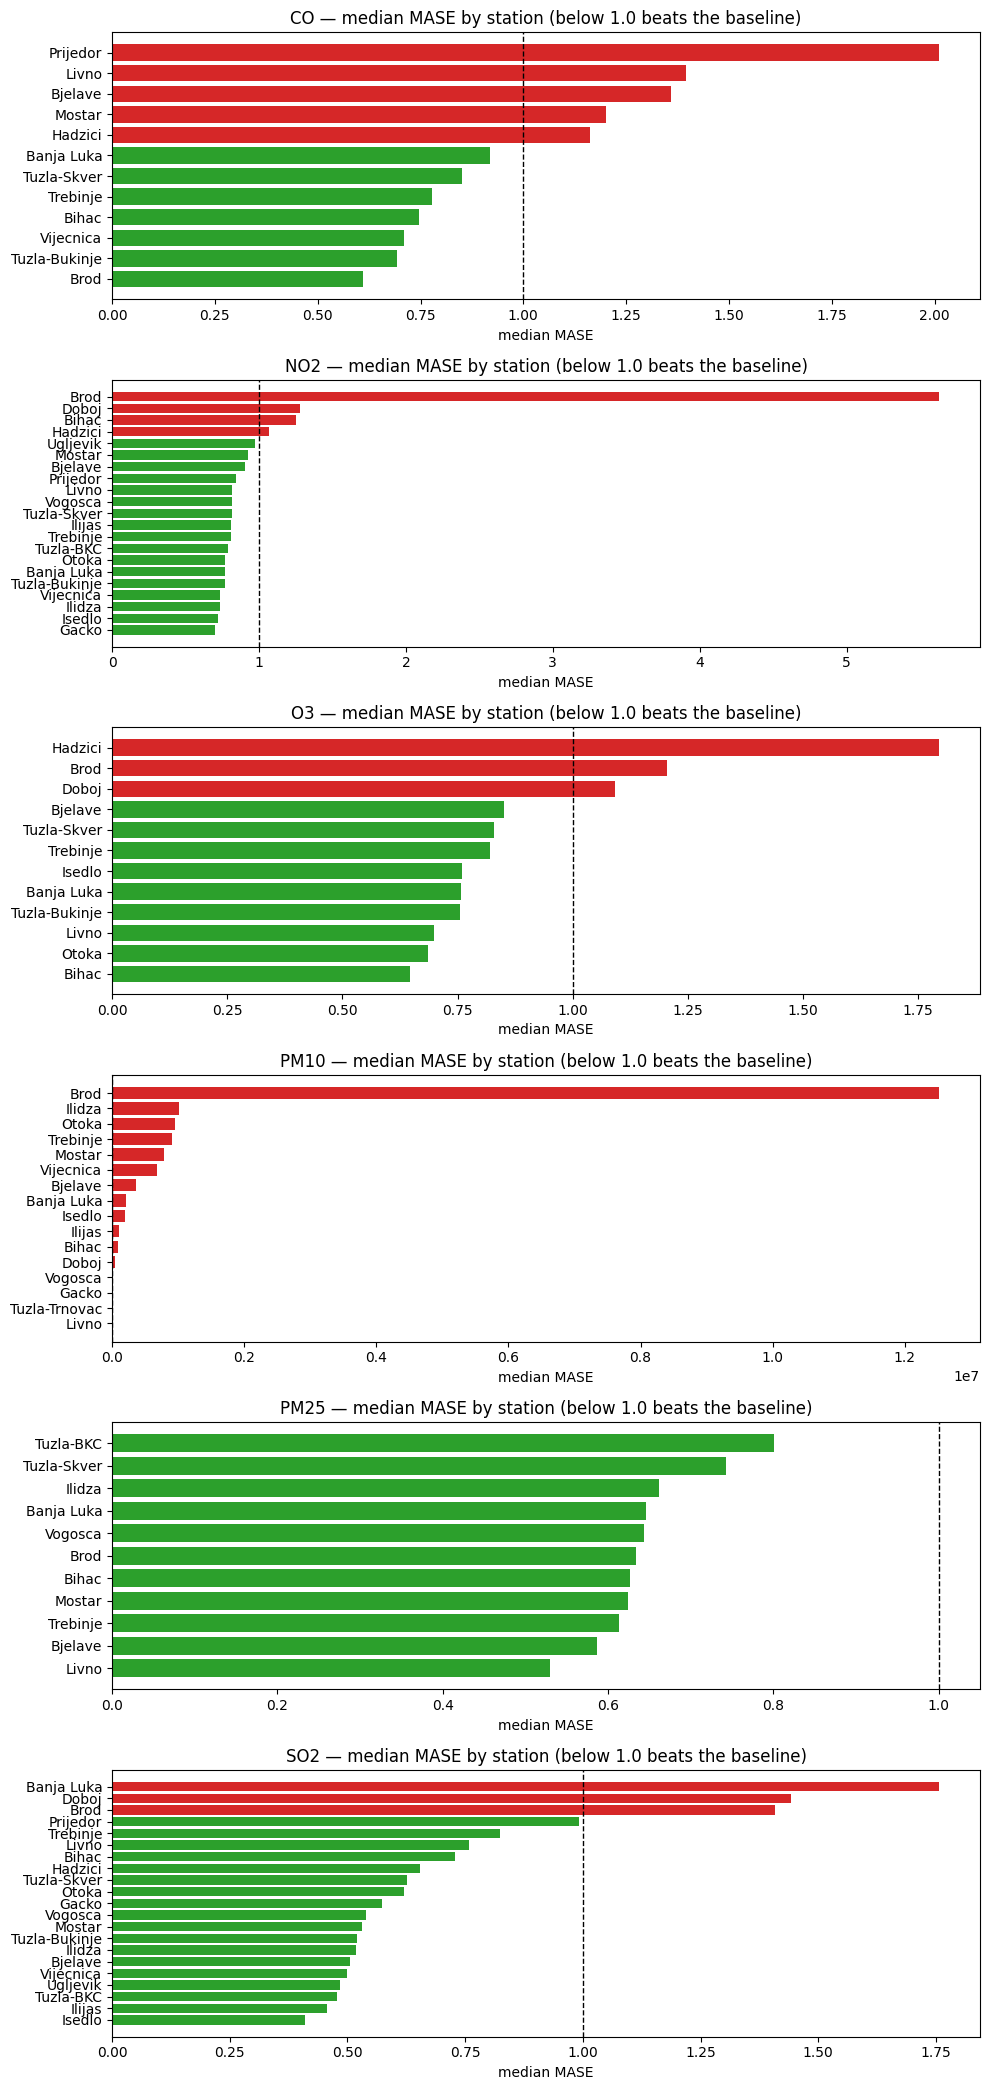

saved xlstm_mase_by_station.png
30,553 total windows across 93 station-pollutant series

MASE BY POLLUTANT (mean + median — median is the trustworthy one)

                    mae          rmse         mase  median_mase
pollutant                                                      
co         4.342200e+01  5.311000e+01      119.698        0.910
no2        2.078891e+03  2.436538e+03      163.112        0.850
o3         2.482722e+04  3.253678e+04     1187.361        0.853
pm10       1.087895e+07  1.349666e+07  1685277.937   209437.435
pm25       9.896000e+00  1.280200e+01        0.845        0.652
so2        8.115350e+02  9.303170e+02      612.978        0.652


HEADLINE — mean over all windows: MAE 1762489.349  RMSE 2186755.853  MASE 272612.969
HEADLINE — median MASE over all windows: 0.907


MASE BY POLLUTANT vs BASELINES (identical windows)

model      persistence_last  persistence_t24  ratio_pm25        xlstm
pollutant                                                            
co  

,mae,rmse,mase,median_mase
pollutant,,,,
co,4.342234e+01,5.310999e+01,1.196982e+02,0.910098
no2,2.078891e+03,2.436538e+03,1.631123e+02,0.849953
o3,2.482722e+04,3.253678e+04,1.187361e+03,0.853304
pm10,1.087895e+07,1.349666e+07,1.685278e+06,209437.434549
pm25,9.895773e+00,1.280193e+01,8.447722e-01,0.651675
so2,8.115354e+02,9.303173e+02,6.129781e+02,0.651932


In [ ]:
plot_results(out_csv=CSV)
final_summary(out_csv=CSV)

# Inspecting the problems with pm10

In [ ]:
full = pd.read_csv(CSV)
pm10 = full[full.pollutant == "pm10"]
bad = pm10.groupby("station").mase.median().sort_values(ascending=False)
print(bad)

station
Brod             1.251370e+07
Ilidza           1.008474e+06
Otoka            9.464099e+05
Trebinje         9.132395e+05
Mostar           7.848032e+05
Vijecnica        6.865801e+05
Bjelave          3.558631e+05
Banja Luka       2.106360e+05
Isedlo           1.999766e+05
Ilijas           1.044573e+05
Bihac            9.030213e+04
Doboj            4.333543e+04
Vogosca          3.024190e+00
Gacko            1.504204e+00
Tuzla-Trnovac    1.122296e+00
Livno            1.089477e+00
Name: mase, dtype: float64


In [ ]:
progress(out_csv=CSV)

95 total pairs
81 done
14 remaining (3 more batches of 5)

next up: [('Banja Luka', 'pm10'), ('Bihac', 'pm10'), ('Bjelave', 'pm10'), ('Brod', 'pm10'), ('Doboj', 'pm10')]


([('Banja Luka', 'pm10'),
  ('Bihac', 'pm10'),
  ('Bjelave', 'pm10'),
  ('Brod', 'pm10'),
  ('Doboj', 'pm10'),
  ('Gacko', 'pm10'),
  ('Ilidza', 'pm10'),
  ('Ilijas', 'pm10'),
  ('Isedlo', 'pm10'),
  ('Livno', 'pm10'),
  ('Mostar', 'pm10'),
  ('Otoka', 'pm10'),
  ('Trebinje', 'pm10'),
  ('Tuzla-Trnovac', 'pm10'),
  ('Vijecnica', 'pm10'),
  ('Vogosca', 'pm10'),
  ('Ambasada', 'pm25'),
  ('Banja Luka', 'pm25'),
  ('Bihac', 'pm25'),
  ('Bjelave', 'pm25'),
  ('Brod', 'pm25'),
  ('Ilidza', 'pm25'),
  ('Livno', 'pm25'),
  ('Mostar', 'pm25'),
  ('Trebinje', 'pm25'),
  ('Tuzla-BKC', 'pm25'),
  ('Tuzla-Skver', 'pm25'),
  ('Vogosca', 'pm25'),
  ('Banja Luka', 'so2'),
  ('Bihac', 'so2'),
  ('Bjelave', 'so2'),
  ('Brod', 'so2'),
  ('Doboj', 'so2'),
  ('Gacko', 'so2'),
  ('Hadzici', 'so2'),
  ('Ilidza', 'so2'),
  ('Ilijas', 'so2'),
  ('Isedlo', 'so2'),
  ('Livno', 'so2'),
  ('Mostar', 'so2'),
  ('Otoka', 'so2'),
  ('Prijedor', 'so2'),
  ('Trebinje', 'so2'),
  ('Tuzla-BKC', 'so2'),
  ('Tuzla-Bukinje

In [ ]:
full = pd.read_csv(CSV)
pm10 = full[full.pollutant == "pm10"]
bad = pm10.groupby("station").mase.median().sort_values(ascending=False)
print(bad)

station
Vogosca          3.024190
Gacko            1.504204
Tuzla-Trnovac    1.122296
Livno            1.089477
Name: mase, dtype: float64


In [ ]:
import gc, torch

bad_stations = bad[bad > 10].index.tolist()
print("retraining:", bad_stations)

full_clean = full[~((full.pollutant == "pm10") & (full.station.isin(bad_stations)))]
full_clean.to_csv(CSV, index=False)

panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)

for station in bad_stations:
    model, val_ds, _, mu, sigma = train_one_station(
        station, "pm10", device=torch.device("cpu"), panel=panel)
    result, _ = evaluate(model, val_ds, panel, station, "pm10", mu, sigma, device=torch.device("cpu"))
    result.to_csv(CSV, mode="a", header=False, index=False)
    del model, val_ds, result
    gc.collect()

retraining: []


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

In [ ]:
final_summary(out_csv=CSV)

26,696 total windows across 81 station-pollutant series

MASE BY POLLUTANT (mean + median — median is the trustworthy one)

                  mae        rmse       mase  median_mase
pollutant                                                
co             43.422      53.110    119.698        0.910
no2          2078.891    2436.538    163.112        0.850
o3          24827.215   32536.776   1187.361        0.853
pm10       677859.866  841511.475  33831.767        1.700
pm25            9.896      12.802      0.845        0.652
so2           811.535     930.317    612.978        0.652


HEADLINE — mean over all windows: MAE 31902.301  RMSE 39798.746  MASE 1765.730
HEADLINE — median MASE over all windows: 0.806


MASE BY POLLUTANT vs BASELINES (identical windows)

model      persistence_last  persistence_t24  ratio_pm25      xlstm
pollutant                                                          
co                    1.394            1.053         NaN    119.698
no2                   1.51

,mae,rmse,mase,median_mase
pollutant,,,,
co,43.422339,53.109993,119.698151,0.910098
no2,2078.890675,2436.537800,163.112304,0.849953
o3,24827.215081,32536.776449,1187.360859,0.853304
pm10,677859.866253,841511.475322,33831.766789,1.699523
pm25,9.895773,12.801927,0.844772,0.651675
so2,811.535445,930.317259,612.978090,0.651932


In [ ]:
run_all(out_csv=CSV, limit=5, device=torch.device("cpu"))

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

81 station-pollutant pairs already in /content/drive/MyDrive/xlstm_checkpoints/xlstm_results.csv, skipping those
95 total pairs, 14 remaining
running this batch: [('Banja Luka', 'pm10'), ('Bihac', 'pm10'), ('Bjelave', 'pm10'), ('Brod', 'pm10'), ('Doboj', 'pm10')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

In [ ]:
# 3. Check progress
progress(out_csv=CSV)

95 total pairs
81 done
14 remaining (3 more batches of 5)

next up: [('Banja Luka', 'pm10'), ('Bihac', 'pm10'), ('Bjelave', 'pm10'), ('Brod', 'pm10'), ('Doboj', 'pm10')]


([('Banja Luka', 'pm10'),
  ('Bihac', 'pm10'),
  ('Bjelave', 'pm10'),
  ('Brod', 'pm10'),
  ('Doboj', 'pm10'),
  ('Gacko', 'pm10'),
  ('Ilidza', 'pm10'),
  ('Ilijas', 'pm10'),
  ('Isedlo', 'pm10'),
  ('Livno', 'pm10'),
  ('Mostar', 'pm10'),
  ('Otoka', 'pm10'),
  ('Trebinje', 'pm10'),
  ('Tuzla-Trnovac', 'pm10'),
  ('Vijecnica', 'pm10'),
  ('Vogosca', 'pm10'),
  ('Ambasada', 'pm25'),
  ('Banja Luka', 'pm25'),
  ('Bihac', 'pm25'),
  ('Bjelave', 'pm25'),
  ('Brod', 'pm25'),
  ('Ilidza', 'pm25'),
  ('Livno', 'pm25'),
  ('Mostar', 'pm25'),
  ('Trebinje', 'pm25'),
  ('Tuzla-BKC', 'pm25'),
  ('Tuzla-Skver', 'pm25'),
  ('Vogosca', 'pm25'),
  ('Banja Luka', 'so2'),
  ('Bihac', 'so2'),
  ('Bjelave', 'so2'),
  ('Brod', 'so2'),
  ('Doboj', 'so2'),
  ('Gacko', 'so2'),
  ('Hadzici', 'so2'),
  ('Ilidza', 'so2'),
  ('Ilijas', 'so2'),
  ('Isedlo', 'so2'),
  ('Livno', 'so2'),
  ('Mostar', 'so2'),
  ('Otoka', 'so2'),
  ('Prijedor', 'so2'),
  ('Trebinje', 'so2'),
  ('Tuzla-BKC', 'so2'),
  ('Tuzla-Bukinje

In [ ]:
# 4. Check available RAM before training
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.6Gi       8.9Gi       2.0Mi       2.2Gi        10Gi
Swap:             0B          0B          0B


In [ ]:

import torch
run_all(out_csv=CSV, limit=5, device=torch.device("cpu"))

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

81 station-pollutant pairs already in /content/drive/MyDrive/xlstm_checkpoints/xlstm_results.csv, skipping those
95 total pairs, 14 remaining
running this batch: [('Banja Luka', 'pm10'), ('Bihac', 'pm10'), ('Bjelave', 'pm10'), ('Brod', 'pm10'), ('Doboj', 'pm10')]
